# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [1]:
import random

class Card:
    def __init__(self, suit, val):
        self.suit = suit
        self.val = val
        
    def __str__(self):
        return str(self.val) + " of " + self.suit

In [2]:
class Deck:
    
    def __init__(self, num_decks=6):
        suits = ["hearts","diamonds","clubs","spades"]
        vals = [2,3,4,5,6,7,8,9,10,"J","Q","K","A"]
        
        self.cards = []
        
        for d in range(num_decks):
            for s in suits:
                for v in vals:
                    self.cards.append(Card(s,v))
        
        random.shuffle(self.cards)
        
        self.cut_card = int(len(self.cards)*0.75)   # plastic card spot
        
    def shuffle(self):
        random.shuffle(self.cards)
        
    def draw(self):
        if len(self.cards) == 0:
            return None
        return self.cards.pop()

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

Card
Deck -> contains many Cards
Hand -> contains Cards
Player -> has a Hand
Dealer -> subclass of Player
Game -> controls players, dealer, and deck

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [7]:
class Hand:
    
    def __init__(self):
        self.cards = []
        
    def add(self, card):
        pass
    
    def value(self):
        pass


class Player:
    
    def __init__(self, name, chips=1000):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        
    def bet(self):
        pass
    
    def play(self, deck):
        pass


class Dealer(Player):
    
    def play(self, deck):
        pass


class Game:
    
    def __init__(self, players):
        self.players = players
        self.deck = Deck()
        
    def round(self):
        pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [12]:
class Hand:
    
    def __init__(self):
        self.cards = []
        
    def add(self, card):
        self.cards.append(card)
        
    def value(self):
        
        total = 0
        aces = 0
        
        for c in self.cards:
            
            if c.val in ["J","Q","K"]:
                total += 10
                
            elif c.val == "A":
                total += 11
                aces += 1
                
            else:
                total += c.val
                
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1
            
        return total
        

class Player:
    
    def __init__(self, name, chips=1000):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        
    def bet(self):
        return 10
        
    def play(self, deck):
        
        while self.hand.value() < 17:
            self.hand.add(deck.draw())


class Dealer(Player):
    
    def __init__(self):
        super().__init__("dealer",999999)
        
    def play(self, deck):
        
        while self.hand.value() < 17:
            self.hand.add(deck.draw())


class Game:
    
    def __init__(self, players):
        
        self.players = players
        self.deck = Deck()
        self.dealer = Dealer()
        
        
    def round(self):
        
        # reshuffle if deck getting low
        if len(self.deck.cards) < 60:
            self.deck = Deck()
        
        
        for p in self.players:
            p.hand = Hand()
            
        self.dealer.hand = Hand()
        
        
        for i in range(2):
            
            for p in self.players:
                card_thing = self.deck.draw()
                if card_thing != None:
                    p.hand.add(card_thing)
                
            d_card = self.deck.draw()
            if d_card != None:
                self.dealer.hand.add(d_card)
        
        
        for p in self.players:
            p.play(self.deck)
            
            
        self.dealer.play(self.deck)
        
        dealer_val = self.dealer.hand.value()
        
        
        for p in self.players:
            
            bet = p.bet()
            val = p.hand.value()
            
            if val > 21:
                p.chips -= bet
                
            elif dealer_val > 21 or val > dealer_val:
                p.chips += bet
                
            elif val < dealer_val:
                p.chips -= bet

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [13]:
p1 = Player("bob")
p2 = Player("goofy")
p3 = Player("weirdguy")

g = Game([p1,p2,p3])

for i in range(5):
    g.round()

print(p1.chips,p2.chips,p3.chips)

970 990 950


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [14]:
class CounterPlayer(Player):
    
    def __init__(self, name, thresh=3):
        super().__init__(name)
        self.count = 0
        self.thresh = thresh
        
    def see_card(self, card):
        
        if card.val in [2,3,4,5,6]:
            self.count += 1
            
        elif card.val in [10,"J","Q","K","A"]:
            self.count -= 1
            
            
    def bet(self):
        
        if self.count >= self.thresh:
            return 50
        else:
            return 10

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [15]:
counter = CounterPlayer("counterdude",3)

p1 = Player("npc1")
p2 = Player("npc2")
p3 = Player("npc3")

g = Game([counter,p1,p2,p3])

for i in range(50):
    g.round()

print("counter chips:",counter.chips)

counter chips: 1000


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


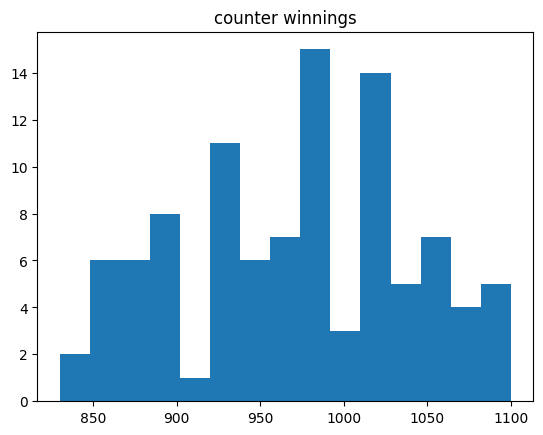

In [16]:
import matplotlib.pyplot as plt

wins = []

for game in range(100):
    
    counter = CounterPlayer("countbro",3)
    
    p1 = Player("a")
    p2 = Player("b")
    p3 = Player("c")
    
    g = Game([counter,p1,p2,p3])
    
    for r in range(50):
        g.round()
        
    wins.append(counter.chips)

plt.hist(wins,bins=15)
plt.title("counter winnings")
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [17]:
tests = [1,2,3,4,5]

for t in tests:
    
    stuff = []
    
    for game in range(50):
        
        counter = CounterPlayer("guy",t)
        
        p1 = Player("x")
        p2 = Player("y")
        p3 = Player("z")
        
        g = Game([counter,p1,p2,p3])
        
        for r in range(50):
            g.round()
            
        stuff.append(counter.chips)
    
    print("threshold",t,"avg",sum(stuff)/len(stuff))

threshold 1 avg 964.6
threshold 2 avg 961.4
threshold 3 avg 949.0
threshold 4 avg 951.4
threshold 5 avg 953.2


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [19]:
class AggroPlayer(Player):
    
    def bet(self):
        
        if self.hand.value() >= 15:
            return 30
        else:
            return 10